In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import davies_bouldin_score

In [3]:
customers = pd.read_csv("Customers.csv")
products = pd.read_csv("Products.csv")
transactions = pd.read_csv("Transactions - Transactions.csv")

In [4]:
merged_df = transactions.merge(customers, on='CustomerID').merge(products, on='ProductID')

In [7]:
customer_features = merged_df.groupby("CustomerID")["TotalValue"].agg(["sum", "mean", "count"])
scaler = StandardScaler()
customer_scaled = scaler.fit_transform(customer_features)
nn = NearestNeighbors(n_neighbors=4, metric='euclidean')  
nn.fit(customer_scaled)

NearestNeighbors(metric='euclidean', n_neighbors=4)

In [8]:
lookalike_results = {}
customer_ids = customer_features.index.tolist()
for i, cust_id in enumerate(customer_ids[:20]):
    distances, indices = nn.kneighbors([customer_scaled[i]])
    lookalikes = [(customer_ids[idx], round(dist, 4)) for idx, dist in zip(indices[0][1:], distances[0][1:])]
    lookalike_results[cust_id] = lookalikes


Customer Segmentation using Clustering

In [9]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(customer_scaled)

Calculating DB index

In [10]:
db_index = davies_bouldin_score(customer_scaled, kmeans_labels)
print("\nDavies-Bouldin Index:", db_index)


Davies-Bouldin Index: 0.8524813520458038


Visualizing Clusters

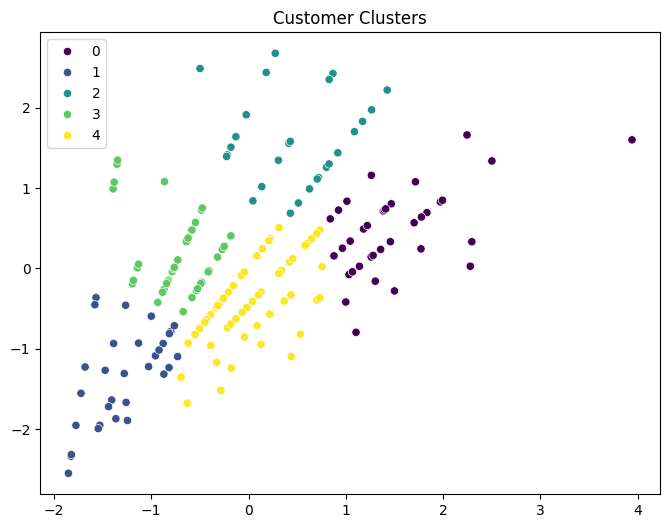

In [11]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=customer_scaled[:, 0], y=customer_scaled[:, 1], hue=kmeans_labels, palette='viridis')
plt.title("Customer Clusters")
plt.show()
